# HCCST performed spatial clustering on Human Intestine A1


## 1. Environment

Import required packages, set random seeds, configure deterministic behavior, and select the running device.


In [1]:
import os
import sys
import json
import time
import warnings
import numpy as np
import pandas as pd
import torch
import scanpy as sc
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
import scipy.sparse as sp

os.environ["PYTHONHASHSEED"] = "42"
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
torch.use_deterministic_algorithms(True)

warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120

# Add the project root path so that local HCCST modules can be imported.
# Modify CODE_ROOT if your project is stored in another directory.
CODE_ROOT = "/root/autodl-tmp"
sys.path.insert(0, CODE_ROOT)

from HCCST.HCCST import MultimodalHCCST
from HCCST.preprocess import fix_seed

random_seed = 42
fix_seed(random_seed)

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)


device = cuda:0


## 2. Parameters

Define dataset paths and hyperparameters. Human Intestine A1 has no reliable spot-level manual annotation, so k-means clustering is used by default and spatial refinement is disabled.


In [2]:
# Dataset identifier and file paths.
dataset = "Intestine_A1"
dataset_name = "Intestine_A1_HCCST"
spatial_dir = "/root/autodl-tmp/Dataset/Intestine/A1/spatial/"
h5ad_path = "/root/autodl-tmp/Dataset/Intestine/A1/10X_Visium_fawkner2021spatiotemporal_A1_data.h5ad"

# Output directory for saving the trained AnnData object, metrics, and figures.
output_dir = "/root/autodl-tmp/outputs/HCCST/Intestine_A1_HCCST"
os.makedirs(output_dir, exist_ok=True)

# Clustering parameters for the unlabeled Human Intestine A1 dataset.
n_clusters = 15
cluster_tool = "kmeans"
radius = 4
refinement = False

# Training parameters.
epochs = 180
dim_output = 48

alpha = 12    # reconstruction loss weight
beta = 0.1    # cross-modal contrastive loss weight
gamma = 0.7   # modality consistency loss weight
delta = 0.1   # prototype regularization loss weight

# Image and multimodal fusion parameters.
image_size = 224
patch_size = 112
embedding_mode = "late_fusion"
embedding_lambda=0.4

print("h5ad_path =", h5ad_path)
print("spatial_dir =", spatial_dir)
print("output_dir =", output_dir)
print("n_clusters =", n_clusters)


h5ad_path = /root/autodl-tmp/Dataset/Intestine/A1/10X_Visium_fawkner2021spatiotemporal_A1_data.h5ad
spatial_dir = /root/autodl-tmp/Dataset/Intestine/A1/spatial/
output_dir = /root/autodl-tmp/outputs/HCCST/Intestine_A1_HCCST
n_clusters = 15


## 3. Helper Functions

Define helper functions for loading histology images, adding 10x-style spatial information, and handling coordinate conversion for visualization.


In [3]:
def find_first_existing(spatial_dir, candidates):
    """Return the first existing file path from a list of candidate file names."""
    for name in candidates:
        path = os.path.join(spatial_dir, name)
        if os.path.exists(path):
            return path
    return None


def load_image_as_array(path):
    """Load a histology image as an RGB NumPy array."""
    return np.asarray(Image.open(path).convert("RGB"))


def load_scalefactors(spatial_dir):
    """Load 10x Visium scalefactors if available; otherwise use scale 1.0."""
    sf_path = os.path.join(spatial_dir, "scalefactors_json.json")
    if not os.path.exists(sf_path):
        print("[Warning] scalefactors_json.json not found; use scale=1.0")
        return {
            "tissue_hires_scalef": 1.0,
            "tissue_lowres_scalef": 1.0,
            "spot_diameter_fullres": 1.0,
        }

    with open(sf_path, "r") as f:
        return json.load(f)


def attach_spatial_uns(adata, spatial_dir, library_id="A1"):
    """
    Add histology image and scalefactor information to adata.uns['spatial'].

    This is useful when the input AnnData object stores expression and coordinates
    but does not include the standard 10x Visium spatial image structure.
    """
    hires_path = find_first_existing(
        spatial_dir,
        [
            "tissue_hires_image.png",
            "tissue_hires_image.jpg",
            "tissue_hires_image.jpeg",
            "hires_image.png",
            "hires.png",
        ],
    )
    lowres_path = find_first_existing(
        spatial_dir,
        [
            "tissue_lowres_image.png",
            "tissue_lowres_image.jpg",
            "tissue_lowres_image.jpeg",
            "lowres_image.png",
            "lowres.png",
        ],
    )

    if hires_path is None:
        raise FileNotFoundError("No high-resolution histology image was found in the spatial directory.")

    images = {"hires": load_image_as_array(hires_path)}
    if lowres_path is not None:
        images["lowres"] = load_image_as_array(lowres_path)

    scalefactors = load_scalefactors(spatial_dir)

    if "spatial" not in adata.uns:
        adata.uns["spatial"] = {}

    adata.uns["spatial"][library_id] = {
        "images": images,
        "scalefactors": scalefactors,
        "metadata": {"source_image_path": hires_path},
    }

    print("hires image:", hires_path, images["hires"].shape)
    print("scalefactors:", scalefactors)

    return adata, images["hires"]


def set_hccst_pixel_spatial(adata):
    """
    Use pixel coordinates as spot coordinates for HCCST.

    HCCST uses row-column coordinates, where spatial[:, 0] is row/y and
    spatial[:, 1] is column/x.
    """
    if "spatial" in adata.obsm:
        adata.obsm["spatial_array_original"] = np.asarray(adata.obsm["spatial"]).copy()

    if "spatial_real" in adata.obsm:
        coord = np.asarray(adata.obsm["spatial_real"], dtype=np.float32).copy()
        source = "spatial_real"
    elif "spatial_pixel" in adata.obsm:
        coord = np.asarray(adata.obsm["spatial_pixel"], dtype=np.float32).copy()
        source = "spatial_pixel"
    elif "spatial" in adata.obsm:
        coord = np.asarray(adata.obsm["spatial"], dtype=np.float32).copy()
        source = "spatial"
    else:
        raise ValueError("No spatial coordinate was found in adata.obsm.")

    adata.obsm["spatial"] = coord.astype(np.float32)

    print(f"Using {source} as adata.obsm['spatial']; coordinate order: row_col")
    print("spatial min:", np.nanmin(adata.obsm["spatial"], axis=0))
    print("spatial max:", np.nanmax(adata.obsm["spatial"], axis=0))

    return adata


def make_scanpy_spatial_plot_adata(adata):
    """
    Create a temporary AnnData object for Scanpy spatial plotting.

    HCCST uses row-column coordinates, while scanpy.pl.spatial treats
    spatial[:, 0] as x and spatial[:, 1] as y. Therefore, coordinates are
    swapped only in the temporary plotting copy.
    """
    adata_plot = adata.copy()
    coord = np.asarray(adata_plot.obsm["spatial"])
    adata_plot.obsm["spatial_hccst_row_col"] = coord.copy()
    adata_plot.obsm["spatial"] = coord[:, [1, 0]].astype(coord.dtype, copy=True)
    return adata_plot


def sample_X_values(adata, n=10000):
    """Sample expression values for a simple data-scale sanity check."""
    X = adata.X
    if sp.issparse(X):
        vals = X.data
    else:
        vals = np.asarray(X).ravel()

    if vals.size == 0:
        return np.array([])

    return vals[: min(n, vals.size)]


## 4. Load Data

Load the AnnData object, attach histology image information, and prepare pixel coordinates for HCCST.


In [4]:
# Load the preprocessed AnnData object.
adata = sc.read_h5ad(h5ad_path)
adata.var_names_make_unique()

print("adata shape:", adata.shape)
print("obs columns:", adata.obs.columns.tolist())
print("obsm keys:", list(adata.obsm.keys()))
print("layers:", list(adata.layers.keys()))
print("raw:", adata.raw)

# Human Intestine A1 is treated as an unlabeled dataset in this example.
# Existing columns such as clusters or leiden are kept only as references and are not used as ground truth.
if "ground_truth" in adata.obs:
    del adata.obs["ground_truth"]

for col in ["clusters", "leiden"]:
    if col in adata.obs:
        print("\nReference column, not ground truth:", col)
        print(adata.obs[col].value_counts().head(20))

# Simple sanity check for the expression matrix.
vals = sample_X_values(adata)
if vals.size:
    print("\nX stats: min", vals.min(), "max", vals.max(), "mean", vals.mean())
    print("integer-like sample:", np.allclose(vals, np.round(vals)))

# Add histology image information and use pixel coordinates for HCCST.
adata, image_data = attach_spatial_uns(adata, spatial_dir, library_id="A1")
adata = set_hccst_pixel_spatial(adata)

print("hires image shape:", image_data.shape)
print("coordinate max:", float(np.nanmax(adata.obsm["spatial"])))


adata shape: (2649, 33538)
obs columns: ['clusters', 'leiden']
obsm keys: ['X_pca', 'X_umap', 'spatial', 'spatial_pixel', 'spatial_real']
layers: []
raw: None

Reference column, not ground truth: clusters
clusters
0    653
1    564
2    527
3    260
4    260
5    186
6    120
7     79
Name: count, dtype: int64

Reference column, not ground truth: leiden
leiden
0    611
1    590
2    366
3    354
4    280
5    276
6     80
7     60
8     32
Name: count, dtype: int64

X stats: min 0.29140866 max 4.6281896 mean 0.69697165
integer-like sample: False
hires image: /root/autodl-tmp/Dataset/Intestine/A1/spatial/tissue_hires_image.png (1906, 2000, 3)
scalefactors: {'spot_diameter_fullres': 54.37959101469902, 'tissue_hires_scalef': 0.28401023, 'fiducial_diameter_fullres': 87.84395471605225, 'tissue_lowres_scalef': 0.08520307}
Using spatial_real as adata.obsm['spatial']; coordinate order: row_col
spatial min: [ 729. 2040.]
spatial max: [5686. 6351.]
hires image shape: (1906, 2000, 3)
coordinate m

## 5. Coordinate Quality Check

Plot spot coordinates on the histology image to verify that the row-column coordinates are correctly aligned with the tissue.


hires height, width = 1906 2000
need_scale = True plot_scale = 0.28401023


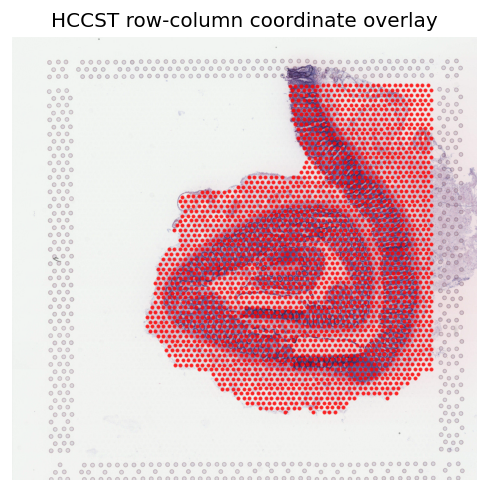

coordinate QC saved: /root/autodl-tmp/outputs/HCCST/Intestine_A1_HCCST/Intestine_A1_HCCST_coordinate_overlay.jpg


In [5]:
lib = adata.uns["spatial"]["A1"]
img = lib["images"]["hires"]
scale = float(lib["scalefactors"].get("tissue_hires_scalef", 1.0))
coords = np.asarray(adata.obsm["spatial"], dtype=float)

# If coordinates are in full-resolution scale, multiply them by the hires scale for plotting.
# If they are already in hires scale, use them directly.
height, width = img.shape[:2]
need_scale = (coords[:, 1].max() > width) or (coords[:, 0].max() > height)
plot_scale = scale if need_scale else 1.0

print("hires height, width =", height, width)
print("need_scale =", need_scale, "plot_scale =", plot_scale)

x = coords[:, 1] * plot_scale
y = coords[:, 0] * plot_scale

plt.close("all")
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.scatter(x, y, s=2, c="red", alpha=0.7)
plt.title("HCCST row-column coordinate overlay")
plt.axis("off")

coord_qc_path = os.path.join(output_dir, f"{dataset_name}_coordinate_overlay.jpg")
plt.savefig(coord_qc_path, dpi=300, bbox_inches="tight")
plt.show()

print("coordinate QC saved:", coord_qc_path)


## 6. Train HCCST

Initialize the multimodal HCCST model and train it to obtain spot-level clustering embeddings.


In [6]:
# Initialize the multimodal HCCST model.
multimodal_model = MultimodalHCCST(
    adata=adata,
    image_data=image_data,
    device=device,
    epochs=epochs,
    dim_output=dim_output,
    random_seed=random_seed,
    alpha=alpha,
    beta=beta,
    gamma=gamma,
    delta=delta,
    num_cell_types=n_clusters,
    embedding_lambda=embedding_lambda,
)

print("morphology adjacency statistics:", multimodal_model.adata.uns.get("mor_adj_stats", None))

if "mor_adj" in multimodal_model.adata.obsm:
    mor_adj = np.asarray(multimodal_model.adata.obsm["mor_adj"])
    vals = mor_adj[mor_adj > 0]
    if vals.size > 0:
        print("mor_adj nonzero quantiles:", np.quantile(vals, [0, 0.1, 0.25, 0.5, 0.75, 0.9, 1]))

# Train the multimodal model.
start_time = time.time()
adata_result = multimodal_model.train_multimodal()
elapsed = time.time() - start_time

print(f"training done, elapsed: {elapsed:.2f} s")
print("clustering embedding:", adata_result.uns.get("emb_key"))


morphology adjacency statistics: {'pca_dim': 16, 'nonzero_edges': 11967, 'mean_weight': 0.9940059781074524, 'topk_keep': None}
mor_adj nonzero quantiles: [0.95735383 0.98547804 0.99112841 0.99557555 0.99917668 1.
 1.        ]


Joint training: 100%|██████████| 126/126 [00:34<00:00,  3.61it/s]


training done, elapsed: 38.47 s
clustering embedding: late_fusion_embedding_lambda_0.4


## 7. Cluster and Evaluate

Cluster the learned HCCST embeddings. Since no reliable manual annotation is available, unsupervised metrics are reported instead of ARI or NMI.


In [16]:
multimodal_model.adata = adata_result.copy()

# Ensure that no ground-truth annotation is used for this unlabeled dataset.
if "ground_truth" in multimodal_model.adata.obs:
    del multimodal_model.adata.obs["ground_truth"]

# Cluster the learned embeddings.
multimodal_model.cluster(
    tool=cluster_tool,
    radius=radius,
    key="emb",
    refinement=refinement,
    n_clusters=n_clusters,
)

adata_result = multimodal_model.adata.copy()
group_key = "domain"
adata_result.obs[group_key] = adata_result.obs[group_key].astype(str)

# Compute a PCA representation of the learned embedding for unsupervised metrics.
emb_mat = np.asarray(adata_result.obsm["emb"])
n_comp = min(30, emb_mat.shape[1], max(1, emb_mat.shape[0] - 1))
adata_result.obsm["emb_pca"] = PCA(
    n_components=n_comp,
    random_state=random_seed,
).fit_transform(emb_mat)

# Calculate unsupervised clustering metrics.
metrics_dict = multimodal_model.calculate_metrics(
    pred_col=group_key,
    true_col="ground_truth",
    mode="unsupervised",
)
metrics_df = pd.DataFrame([metrics_dict], index=["HCCST"])

# Extract the silhouette coefficient for output naming.
# The final file prefix follows: Human_Intestine_Cancer_SC{SC:.4f}.
sc_key_candidates = ["SC"]
SC = next((float(metrics_df.loc["HCCST", key]) for key in sc_key_candidates if key in metrics_df.columns), float("nan"))

print(metrics_df)


             SC          CH        DB     S_Dbw
HCCST  0.339517  3084.18512  1.058057  0.310803


## 8. Save and Visualize

Save the clustering results and visualize the predicted spatial domains on the histology image.


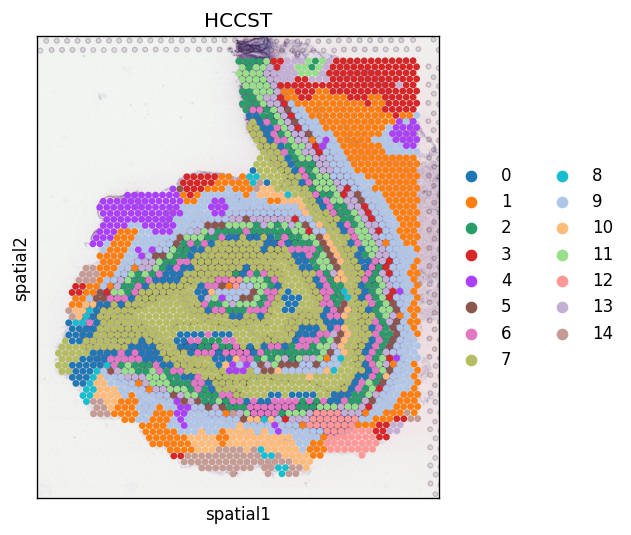

h5ad: /root/autodl-tmp/outputs/HCCST/Intestine_A1_HCCST/Human_Intestine_Cancer_SC0.340.h5ad
spatial: /root/autodl-tmp/outputs/HCCST/Intestine_A1_HCCST/Human_Intestine_Cancer_SC0.340_spatial.jpg


In [20]:
# Use the requested naming rule for all saved clustering outputs.
file_prefix = f"Human_Intestine_Cancer_SC{SC:.3f}"
h5ad_save_path = os.path.join(output_dir, f"{file_prefix}.h5ad")
spatial_path = os.path.join(output_dir, f"{file_prefix}_spatial.jpg")

# Save the final AnnData object with HCCST embeddings and predicted domains.
adata_result.write(h5ad_save_path)

# Visualize spatial domains on the histology image.
# A temporary copy is used to convert HCCST row-column coordinates to Scanpy x-y coordinates.
adata_spatial_plot = make_scanpy_spatial_plot_adata(adata_result)

plt.close("all")
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.spatial(
    adata_spatial_plot,
    img_key="hires",
    color=group_key,
    size=1.5,
    title="HCCST",
    show=False,
)
plt.savefig(spatial_path, bbox_inches="tight", dpi=300)
plt.show()

print("h5ad:", h5ad_save_path)
print("spatial:", spatial_path)
